# 実行例6.5 : アヤメデータ（p.40 図4.2(a), p.79 図6.5(b)）

In [1]:
using Pkg
Pkg.activate(@__DIR__)
using Statistics
using LinearAlgebra
using Random
using Distributions
using DataFrames
using CairoMakie

  Activating project at `c:\Users\salt_\OneDrive\Documents\!勉強\Julia\Pattern_recognition`


### 1. アヤメデータの準備（p.40 図4.2(a)）
- `iris_01-simple_plot.ipynb`流用

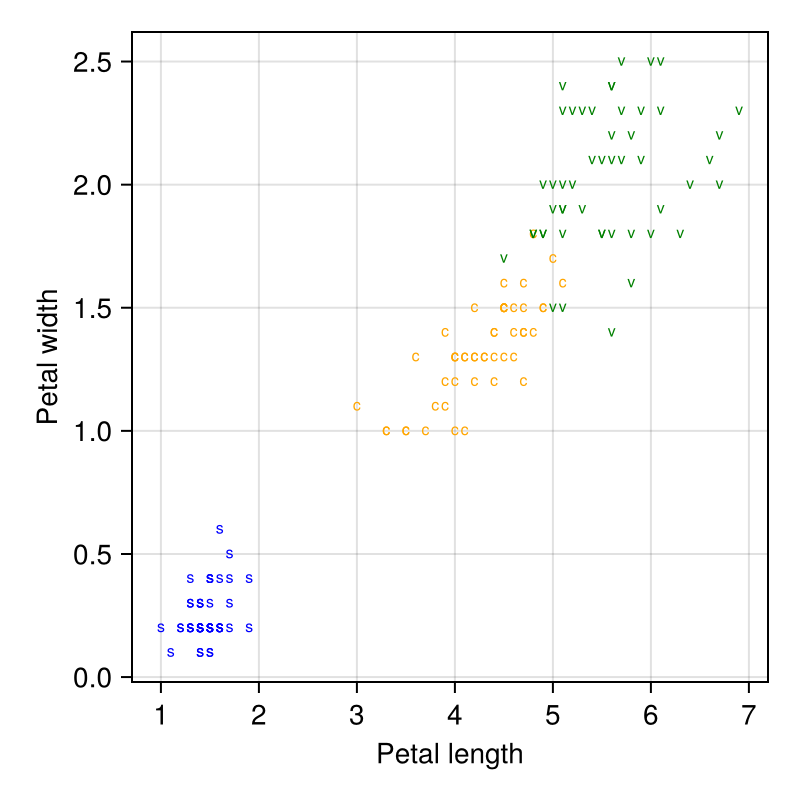

In [2]:
# (1)iris.csvのファイal_length_x, sepal_width_x, petal_length_xルパスを設定する
filepath = joinpath(@__DIR__, "iris.csv")

# (2)iris.csv（filepath）を読み出す
lines = open(filepath, "r") do io
    Iterators.drop(eachline(io), 1) |> collect
end

# (3)データ配列の準備
sepal_length = Float64[]    # がく片の長さ
sepal_width = Float64[]     # がく片の幅
petal_length = Float64[]    # 花弁の長さ
petal_width = Float64[]     # 花弁の幅
Species = String[]          # 種別

# (4)読み出した行をカンマ区切りのデータ配列にする
for line in lines
    rownames, sepal_length_x, sepal_width_x, petal_length_x, petal_width_x, species_x = split(line, ",")

    # 配列に挿入
    push!(sepal_length, parse(Float64, sepal_length_x))
    push!(sepal_width, parse(Float64, sepal_width_x))
    push!(petal_length, parse(Float64, petal_length_x))
    push!(petal_width, parse(Float64, petal_width_x))
    push!(Species, strip(species_x))  # 両端の空白を削除してから挿入
end

# (5)プロット
# マークと色の指定
marker_dict = Dict(
    "setosa" => 's', 
    "versicolor" => 'c', 
    "virginica" => 'v')
markers = [marker_dict[s] for s in Species]
color_dict = Dict(
    "setosa" => :blue, 
    "versicolor" => :orange, 
    "virginica" => :green)
colors = [color_dict[s] for s in Species]
# CairoMakieで描画
fig = Figure(size = (400, 400))
ax = Axis(fig[1, 1],
        xlabel="Petal length",
        ylabel="Petal width",
        xticks=1.0:1.0:7.0,
        yticks=0.0:0.5:2.5)
plt = scatter!(ax, petal_length, petal_width,
        marker=markers,
        color=colors,
        markersize=8)

fig

### 2. 最大識別関数法（p.79 図6.5(b)）
- 「最大識別関数法」という言葉はあまり一般的ではないらしい。
- 多クラス問題の最小2乗誤差基準による線形識別関数<br>
学習データ : $X = (x_1, \cdots ,x_N)^T$<br>
教師データ : $T = (t_1, \cdots, t_N)^T, t_i = \underbrace{(0, \cdots, 1, \cdots, 0)^T}_{K個の要素}$<br>
<br>
2乗誤差を最小にするパラメーター $\hat{W}$ : $\hat{W} = (X^T X)^{-1} X^T X$<br>
識別関数 : $f(x) = \hat{W}^T x = (w_1, \cdots ,w_N)^T x = (f_1(x), \cdots, f_k(x))^T$<br>
識別規則 : $\text{識別クラス}　= arg \, \underset{j}{max} \, f_j(x)$
- `t(c) = Float64.(1:K .== c)` :  `1:K .== c` でc番目だけ`true`の`BitVector`を作り`Float64.()`で変換
- `repeat(..., n)` :  同じ行をn回繰り返す
- `repeat(t(c), 1, n)` : `t(c)`をn列並べたK×n行列
- `hcat(...)` : horizontal concatenation、横方向に結合
- `vcat(...)` : vertical concatenation、縦方向に結合
- `...` : スプラット演算子（配列をバラして個々の引数として展開）。そのまま渡すと`Tc`が1つの配列として扱われるためエラーになる。
- `contour!()`の引数
    - `ax` — 描画先の軸
    - `x1_range` — x軸方向のグリッド座標（range で作った値列）
    - `x2_range` — y軸方向のグリッド座標
    - `class_map` — グリッド各点のクラス番号（Float64の2次元配列、サイズは length(x2_range) × length(x1_range)）
    - `levels=[1.5, 2.5]` — この値の等値線を引く。クラス1→2の境界が1.5、クラス2→3の境界が2.5

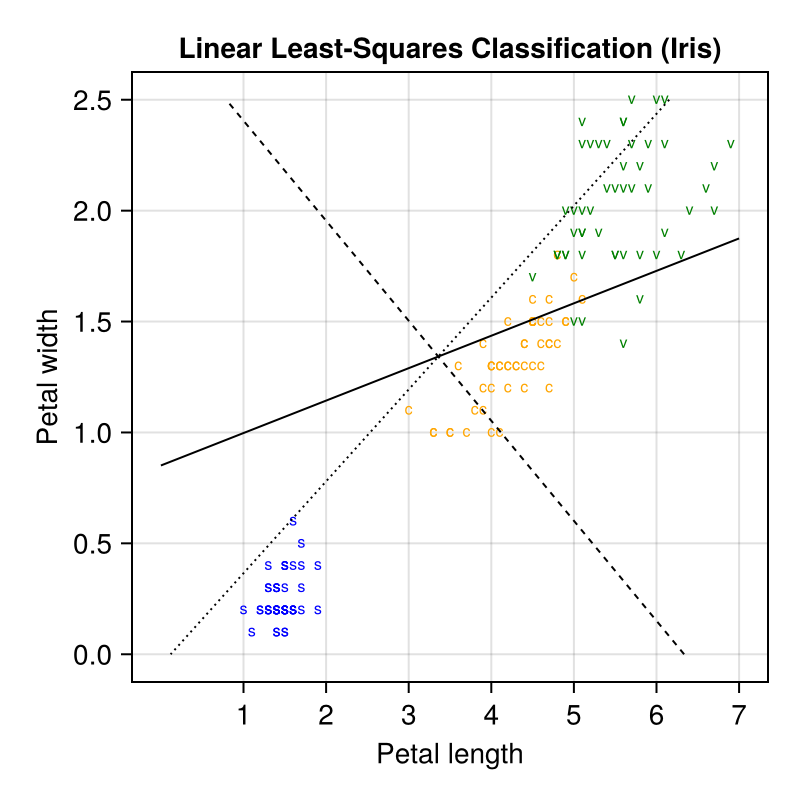

In [3]:
# (1)学習データ
N = length(Species)
# Xc = [[petal_length[i], petal_width[i]] for i in 1:N] 
Xc = [[1.0, petal_length[i], petal_width[i]] for i in 1:N]    # バイアス項を追加
Xt = hcat(Xc...)
X = transpose(Xt)

# (2)教師データ
K = 3
Tc = Vector{Float64}[]   # 3要素、初期値未定義
for i in 1:N
    if Species[i] == "setosa"
        push!(Tc, [1.0, 0.0, 0.0])
    elseif Species[i] == "versicolor"
        push!(Tc, [0.0, 1.0, 0.0])
    elseif Species[i] == "virginica"
        push!(Tc, [0.0, 0.0, 1.0])
    end
end
T = transpose(hcat(Tc...))

# (3)2乗誤差のパラメーター
W_hat = inv(Xt * X) * Xt * T

# (4)識別関数
function discriminant(x::Vector)
    fx = transpose(W_hat) * x
    return fx
end

# (5)グリッドの設定
length_range = range(0.0, 7.0, length=300)
width_range = range(0.0, 2.5, length=300)

# (6)各グリッド点のクラス（argmax）を計算
# class_map = [Float64(argmax(discriminant([length, width])))
#              for width in width_range, length in length_range]
class_map = [Float64(argmax(discriminant([1.0, length, width])))
             for width in width_range, length in length_range]    # バイアス項を追加

# (7)既存のaxに決定境界を追加（クラスが切り替わる等値線）
styles = [:solid, :dash, :dot]
# contour!(ax, length_range, width_range, class_map,
#          levels=[1.5, 2.5],
#          color=:red,
#          linewidth=1)
for ((i, j), style) in zip([(1,2), (1,3), (2,3)], styles)
    z = [(W_hat[:,i] - W_hat[:,j]) ⋅ [1.0, x1, x2]
         for x2 in width_range, x1 in length_range]
    contour!(ax, length_range, width_range, z,
             levels=[0.0], 
             color=:black,
             linestyle=style, 
             linewidth=1)
end
ax.title = "Linear Least-Squares Classification (Iris)"
save("iris_least_squares.png", fig)
fig

In [5]:
# (1)交点の計算
# W_hat は 3×3（バイアス込み）
# f_i(x) = W_hat[:,i]' * [1, x1, x2]
# f1 = f2 かつ f2 = f3 → 2本の方程式、2つの未知数 (x1, x2)

A = [(W_hat[:,1] - W_hat[:,2])[2:3]';   # x1, x2 の係数
     (W_hat[:,2] - W_hat[:,3])[2:3]']

b = -[(W_hat[:,1] - W_hat[:,2])[1],     # バイアス項を右辺に移項
      (W_hat[:,2] - W_hat[:,3])[1]]

x_cross = A \ b   # 交点座標 [x1, x2]

2-element Vector{Float64}:
 3.7580000000000013
 1.1993333333333347